# Deep Learning Frameworks Practice

---

Welcome to your hands-on practice with deep learning frameworks! Today you'll get comfortable with **TensorFlow/Keras** and see a comparison with **PyTorch**.

By the end of this notebook, you will:
- Build neural networks using Keras (the beginner-friendly approach)
- Train a model on real data
- Make predictions with your trained model
- See how the same network looks in PyTorch

**Remember from the slides:**
> *"Keras is like a pre-built kit — all the pieces are ready to snap together. You focus on what you want to build, not how to build it."*

---

# PART 1: WALKTHROUGH

---

## 1.1 Setup and Imports

In [ ]:
# !pip install tensorflow torch scikit-learn matplotlib  # uncomment if needed

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)
print("\n✅ All imports successful!")

TensorFlow version: 2.16.1
PyTorch version: 2.6.0

✅ All imports successful!


---

## 1.2 Tensors - The Building Blocks

**What is a tensor?** A multi-dimensional array (like NumPy arrays!)
- 0D = scalar, 1D = vector, 2D = matrix, 3D+ = tensor

Both TensorFlow and PyTorch are named after tensors!

### Creating Tensors in TensorFlow

In [2]:
tf_tensor = tf.constant([1, 2, 3, 4, 5])  # from Python list
print("TensorFlow tensor:", tf_tensor)
print("Shape:", tf_tensor.shape)

TensorFlow tensor: tf.Tensor([1 2 3 4 5], shape=(5,), dtype=int32)
Shape: (5,)


2026-02-11 18:45:21.709320: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-11 18:45:21.709384: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-11 18:45:21.709418: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-02-11 18:45:21.709702: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-11 18:45:21.709733: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
numpy_array = np.array([[1, 2, 3], [4, 5, 6]])
tf_from_numpy = tf.constant(numpy_array)  # from NumPy
print("NumPy array:\n", numpy_array)
print("\nTensorFlow tensor:\n", tf_from_numpy)
print("\nShape:", tf_from_numpy.shape)

NumPy array:
 [[1 2 3]
 [4 5 6]]

TensorFlow tensor:
 tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int64)

Shape: (2, 3)


### Creating Tensors in PyTorch

In [4]:
pt_from_numpy = torch.from_numpy(numpy_array)  # from NumPy
print("PyTorch tensor:\n", pt_from_numpy)
print("\nShape:", pt_from_numpy.shape)

PyTorch tensor:
 tensor([[1, 2, 3],
        [4, 5, 6]])

Shape: torch.Size([2, 3])


**Key Takeaway:** Both frameworks work with tensors similarly. If you know NumPy, you're already halfway there!

---

## 1.3 Our Dataset: Iris Flowers

Before we build a model, let's understand what we're working with!

The **Iris dataset** is a classic in machine learning: 150 flowers, 4 measurements, 3 species.

In [5]:
iris = load_iris()
X, y = iris.data, iris.target

print("Features (X):", X.shape)  # 150 samples, 4 features
print("Labels (y):", y.shape)    # 150 labels
print("\nFeature names:", iris.feature_names)
print("Class names:", iris.target_names)

Features (X): (150, 4)
Labels (y): (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']


In [6]:
print("First 5 samples:")
print(X[:5])
print("\nFirst 5 labels:", y[:5], "← 0=setosa, 1=versicolor, 2=virginica")

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 labels: [0 0 0 0 0] ← 0=setosa, 1=versicolor, 2=virginica


**So our neural network needs:**
- **4 input neurons** (one for each feature: sepal length, sepal width, petal length, petal width)
- **3 output neurons** (one for each class: setosa, versicolor, virginica)

### Splitting Data: Train, Validation, Test

We need THREE sets of data:
- **Training set** (60%): Model learns from this
- **Validation set** (20%): Check progress during training, tune hyperparameters
- **Test set** (20%): Final evaluation - model never sees this until the end!

In [7]:
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: separate train and validation from remaining data (75/25 of 80% = 60/20 overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Training:   {len(X_train)} samples (60%)")
print(f"Validation: {len(X_val)} samples (20%)")
print(f"Test:       {len(X_test)} samples (20%)")

Training:   90 samples (60%)
Validation: 30 samples (20%)
Test:       30 samples (20%)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data only!
X_val_scaled = scaler.transform(X_val)          # transform validation
X_test_scaled = scaler.transform(X_test)        # transform test

print("Before scaling:", X_train[0])
print("After scaling: ", X_train_scaled[0])

Before scaling: [7.7 2.8 6.7 2. ]
After scaling:  [ 2.23179814 -0.67959102  1.66256055  1.05988727]


---

## 1.4 Your First Keras Model

**The 3-Step Keras Recipe:**
1. **Define** the layers
2. **Compile** (choose optimizer, loss, metrics)
3. **Fit** (train!)

**Simple activation rules:**
- Hidden layers → `'relu'`
- Output (multi-class) → `'softmax'`

### Step 1: Define the Layers

We know we need **4 inputs** and **3 outputs**. Let's add some hidden layers in between!

In [9]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),  # 4 inputs → 16 neurons
    layers.Dense(8, activation='relu'),                      # 16 → 8 neurons
    layers.Dense(3, activation='softmax')                    # 8 → 3 outputs
])
print("✅ Model created!")

/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model created!


In [10]:
if 'model' not in globals():
    model = keras.Sequential([
        layers.Dense(16, activation='relu', input_shape=(4,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    print("✅ Model created (guard)!" )
else:
    print("✅ Model already exists.")

✅ Model already exists.


In [ ]:
model.summary()

**Understanding the Summary:**
- **Param #:** trainable weights = (inputs × neurons) + biases
- Layer 1: (4 × 16) + 16 = 80 params
- Layer 2: (16 × 8) + 8 = 136 params
- Layer 3: (8 × 3) + 3 = 27 params

### Step 2: Compile the Model

In [11]:
model.compile(
    optimizer='adam',                          # how to update weights
    loss='sparse_categorical_crossentropy',    # how to measure mistakes
    metrics=['accuracy']                       # what to track
)
print("✅ Model compiled!")

✅ Model compiled!


### Step 3: Train!

In [12]:
history = model.fit(
    X_train_scaled, y_train,            # training data
    epochs=100,                          # times through the data
    batch_size=16,                       # samples per update
    validation_data=(X_val_scaled, y_val),  # validation data
    verbose=1
)

Epoch 1/100


2026-02-11 18:46:02.421164: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.5111 - loss: 1.0089 - val_accuracy: 0.4333 - val_loss: 0.9552
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.8888 - val_accuracy: 0.4333 - val_loss: 0.8740
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5667 - loss: 0.7939 - val_accuracy: 0.6000 - val_loss: 0.8088
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6889 - loss: 0.7172 - val_accuracy: 0.5667 - val_loss: 0.7589
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6889 - loss: 0.6579 - val_accuracy: 0.5667 - val_loss: 0.7197
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6889 - loss: 0.6140 - val_accuracy: 0.5667 - val_loss: 0.6889
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7000 - loss: 0.5806 - val_accuracy: 0.5667 - val_loss: 0.6641
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7000 - loss: 0.5553 - val_accuracy: 0.6333 - val_loss: 0.6433
Epo

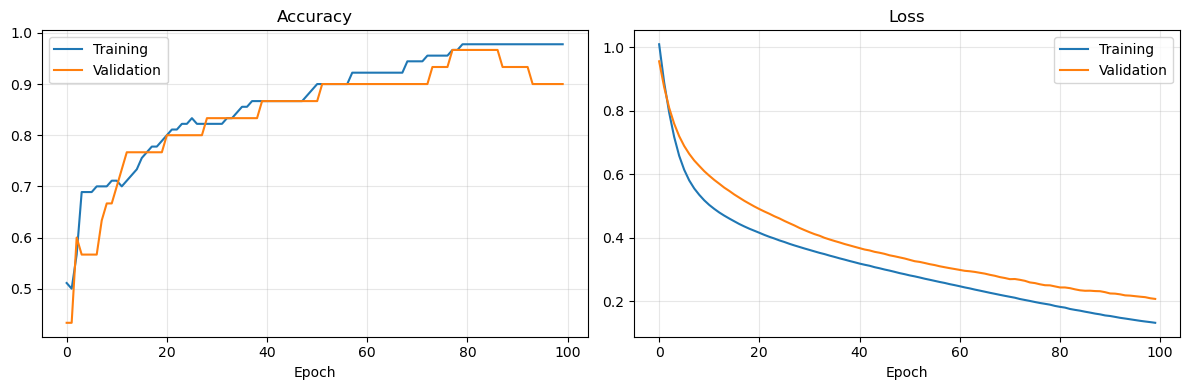

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [14]:
# Final evaluation on TEST set (model has never seen this data!)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\n🎯 Final Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.1186

🎯 Final Test Accuracy: 1.0000


---

## 1.5 A Taste of PyTorch

Same network, different style. PyTorch requires a class definition and manual training loop.

In [15]:
import torch.nn.functional as F

X_train_pt = torch.FloatTensor(X_train_scaled)  # convert to PyTorch tensors
y_train_pt = torch.LongTensor(y_train)
X_val_pt = torch.FloatTensor(X_val_scaled)
y_val_pt = torch.LongTensor(y_val)
X_test_pt = torch.FloatTensor(X_test_scaled)
y_test_pt = torch.LongTensor(y_test)
print(f"Converted to PyTorch tensors: train={X_train_pt.shape}, val={X_val_pt.shape}, test={X_test_pt.shape}")

Converted to PyTorch tensors: train=torch.Size([90, 4]), val=torch.Size([30, 4]), test=torch.Size([30, 4])


In [16]:
class IrisClassifier(nn.Module):  # PyTorch models are classes
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 16)   # same architecture!
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 3)
    
    def forward(self, x):  # define data flow
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

pytorch_model = IrisClassifier()
print(pytorch_model)

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
)


In [17]:
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

print("Training PyTorch model...")
for epoch in range(100):  # manual training loop
    pytorch_model.train()
    outputs = pytorch_model(X_train_pt)
    loss = criterion(outputs, y_train_pt)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        pytorch_model.eval()
        with torch.no_grad():
            val_outputs = pytorch_model(X_val_pt)
            _, val_pred = torch.max(val_outputs, 1)
            val_acc = (val_pred == y_val_pt).sum().item() / len(y_val_pt)
        print(f"Epoch {epoch+1}/100, Loss: {loss.item():.4f}, Val Acc: {val_acc:.4f}")

print("Done!")

Training PyTorch model...
Epoch 20/100, Loss: 0.4491, Val Acc: 0.8333
Epoch 40/100, Loss: 0.1324, Val Acc: 0.9333
Epoch 60/100, Loss: 0.0386, Val Acc: 0.9000
Epoch 80/100, Loss: 0.0179, Val Acc: 0.9000
Epoch 100/100, Loss: 0.0099, Val Acc: 0.9000
Done!


In [18]:
pytorch_model.eval()
with torch.no_grad():
    outputs = pytorch_model(X_test_pt)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test_pt).sum().item() / len(y_test_pt)
print(f"PyTorch Test Accuracy: {accuracy:.4f}")

PyTorch Test Accuracy: 0.9667


### Side-by-Side Comparison

In [19]:
print("KERAS vs PYTORCH")
print("="*50)
print("""
KERAS (~5 lines):
  model = keras.Sequential([...])
  model.compile(optimizer='adam', loss='...')
  model.fit(X_train, y_train, validation_data=(X_val, y_val))

PYTORCH (class + loop):
  class Model(nn.Module): ...
  for epoch in range(100):
      outputs = model(X_train)
      loss.backward()
      optimizer.step()

Both create the same neural network!
""")

KERAS vs PYTORCH

KERAS (~5 lines):
  model = keras.Sequential([...])
  model.compile(optimizer='adam', loss='...')
  model.fit(X_train, y_train, validation_data=(X_val, y_val))

PYTORCH (class + loop):
  class Model(nn.Module): ...
  for epoch in range(100):
      outputs = model(X_train)
      loss.backward()
      optimizer.step()

Both create the same neural network!



---

## 1.6 Quick Reference

```python
# CREATE
model = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(n,)), ...])

# COMPILE
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# TRAIN
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val))

# EVALUATE & PREDICT
model.evaluate(X_test, y_test)
predictions = model.predict(X_new)
```

| Rule | Value |
|------|-------|
| Hidden activation | `'relu'` |
| Output (multi-class) | `'softmax'` |
| Output (binary) | `'sigmoid'` |
| Optimizer | `'adam'` |
| Loss (multi-class) | `'sparse_categorical_crossentropy'` |

---

# PART 2: PRACTICE EXERCISES

---

## Exercise 1: Create Tensors

Create tensors representing 5 students' exam scores in 3 subjects.

In [25]:
student_scores = [
    [85, 90, 88],  # Student 1
    [66, 85, 99],
    [89, 81, 92],
    [71, 67, 88],
    [83, 75, 93]
]

tf_scores = tf.constant(student_scores)  # YOUR CODE HERE
pt_scores = torch.tensor(student_scores)  # YOUR CODE HERE

print("TensorFlow:", tf_scores)
print("PyTorch:", pt_scores)

TensorFlow: tf.Tensor(
[[85 90 88]
 [66 85 99]
 [89 81 92]
 [71 67 88]
 [83 75 93]], shape=(5, 3), dtype=int32)
PyTorch: tensor([[85, 90, 88],
        [66, 85, 99],
        [89, 81, 92],
        [71, 67, 88],
        [83, 75, 93]])


---

## Exercise 2: Build a Deeper Model

Build: 4 inputs → 32 neurons → 16 neurons → 8 neurons → 3 outputs

In [26]:
my_model = keras.Sequential([
    # YOUR CODE HERE - 4 layers total
    # Hint: layers.Dense(32, activation='relu', input_shape=(4,)),
    # ...
    layers.Dense(32, activation='relu', input_shape=(4,)),  # 4 inputs → 16 neurons
    layers.Dense(16, activation='relu'),                      # 16 → 8 neurons
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')                    # 8 → 3 outputs
])

my_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
my_model.summary()

# Uncomment to train after adding layers:
my_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_data=(X_val_scaled, y_val), verbose=1)
print(f"\n🎯 Test Accuracy: {my_model.evaluate(X_test_scaled, y_test, verbose=0)[1]:.4f}")

/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851 (3.32 KB)

 Trainable params: 851 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6444 - loss: 0.6291 - val_accuracy: 0.6333 - val_loss: 0.6196
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6111 - loss: 0.5465 - val_accuracy: 0.7000 - val_loss: 0.5709
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7111 - loss: 0.4830 - val_accuracy: 0.7333 - val_loss: 0.5365
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7556 - loss: 0.4435 - val_accuracy: 0.7333 - val_loss: 0.5139
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8000 - loss: 0.4179 - val_accuracy: 0.7667 - val_loss: 0.5009
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8000 - loss: 0.4016 - val_accuracy: 0.7667 - val_loss: 0.4859
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8000 - loss: 0.3863 - val_accuracy: 0.7667 - val_loss: 0.4702
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8333 - loss: 0.3740 - val_accuracy: 0.7667 - val_loss:

---

## Exercise 3: Predict Mystery Flowers

In [27]:
mystery_flowers = np.array([
    [6.3, 3.3, 4.7, 1.6],
    [5.8, 2.7, 5.1, 1.9],
    [4.9, 3.1, 1.5, 0.1],
])

# YOUR CODE: scale, predict, print species names
mystery_scaled = scaler.transform(mystery_flowers)  # scale using training scaler
predictions = my_model.predict(mystery_scaled)  # get probabilities
predicted_classes = np.argmax(predictions, axis=1)  # get class indices
species_names = iris.target_names[predicted_classes]  # map to species names
print("\nMystery Flowers Predictions:")
for i, species in enumerate(species_names):
    print(f"Flower {i+1}: {species} (class {predicted_classes[i]})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

Mystery Flowers Predictions:
Flower 1: versicolor (class 1)
Flower 2: virginica (class 2)
Flower 3: setosa (class 0)


---

## Exercise 4 (Challenge): Wine Dataset

In [23]:
# Build a classifier: split into train/val/test, scale, create model (13 inputs!), train, evaluate
# Try to get > 95% accuracy!



In [32]:
from sklearn.datasets import load_wine
wine = load_wine()
print(f"Wine: {wine.data.shape[1]} features, {len(wine.target_names)} classes")

X, y = wine.data, wine.target

print("Features (X):", X.shape)  # 178 samples, 13 features
print("Labels (y):", y.shape)    # 178 labels
print("\nFeature names:", wine.feature_names)
print("Class names:", wine.target_names)

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: separate train and validation from remaining data (75/25 of 80% = 60/20 overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Training:   {len(X_train)} samples (60%)")
print(f"Validation: {len(X_val)} samples (20%)")
print(f"Test:       {len(X_test)} samples (20%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data only!
X_val_scaled = scaler.transform(X_val)          # transform validation
X_test_scaled = scaler.transform(X_test)        # transform test

print("Before scaling:", X_train[0])
print("After scaling: ", X_train_scaled[0])

model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(13,)),  # 13 inputs → 32 neurons
    layers.Dense(16, activation='relu'),                      # 32 → 16 neurons
    layers.Dense(8, activation='relu'),                       # 16 → 8 neurons
    layers.Dense(3, activation='softmax')                    # 8 → 3 outputs
])
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\n🎯 Final Test Accuracy: {test_acc:.4f}")



Wine: 13 features, 3 classes
Features (X): (178, 13)
Labels (y): (178,)

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names: ['class_0' 'class_1' 'class_2']
Training:   106 samples (60%)
Validation: 36 samples (20%)
Test:       36 samples (20%)
Before scaling: [1.374e+01 1.670e+00 2.250e+00 1.640e+01 1.180e+02 2.600e+00 2.900e+00
 2.100e-01 1.620e+00 5.850e+00 9.200e-01 3.200e+00 1.060e+03]
After scaling:  [ 0.87880076 -0.62400647 -0.47913939 -0.97248172  1.27288226  0.43909409
  0.87733075 -1.30605031  0.01340158  0.33843125 -0.07921066  0.81745627
  1.09740227]


/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7264 - loss: 0.7161 - val_accuracy: 0.7500 - val_loss: 0.6480
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8019 - loss: 0.5557 - val_accuracy: 0.8333 - val_loss: 0.5242
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8491 - loss: 0.4415 - val_accuracy: 0.8056 - val_loss: 0.4366
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8679 - loss: 0.3637 - val_accuracy: 0.8889 - val_loss: 0.3763
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8774 - loss: 0.3130 - val_accuracy: 0.9167 - val_loss: 0.3393
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8868 - loss: 0.2790 - val_accuracy: 0.9167 - val_loss: 0.3111
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8962 - loss: 0.2517 - val_accuracy: 0.9444 - val_loss: 0.2892
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8962 - loss: 0.2312 - val_accuracy: 0.9444 - val_loss: 0.2750


---

## You Did It! 🎉

You've built neural networks with Keras, trained on real data, made predictions, and seen PyTorch!

**Remember:** The concepts transfer between frameworks.